In [1]:
import wave
import os
import numpy as np
import random
import matplotlib.pyplot as plt
import scipy.io.wavfile as wavfile
from wavTools import * #调用工具包
import tensorflow as tf
import nextpow2
import math
from feature_extractor.features_extractor import extractor

D:\anaconda\lib\site-packages\pkg_resources\__init__.py:122: PkgResourcesDeprecationWarning: py is an invalid version and will not be supported in a future release
  warnings.warn(


In [1]:
#将所有文件切分为28秒
def clip_audio():
    #所需文件路径
    split_path='split_data'
    Classlist=['train','test']
    for i in Classlist:#分为train和test
        if i=='train':
            print("train_data_processing")
        else:
            print("test_data_processing")
  
        Classnames=os.listdir(os.path.join(split_path,i))#分为AD，等
        for Class in Classnames:
            filenames=os.listdir(os.path.join(split_path,i,Class))#当前类中的文件名列表
            num=0
            for file in filenames:
                num=num+1
                start_time = 0
                end_time = 28000
                new_name=str(num)+'.wav'
                main_wav_path=os.path.join(split_path,i,Class,file)
                part_wav_path=os.path.join(split_path,i,Class,new_name)
                get_ms_part_wav(main_wav_path, start_time, end_time, part_wav_path)
        print("clip complete!------")

In [6]:
def berouti(SNR):
    a1=0
    if -5.0 <= SNR <= 20.0:
        a1 = 4 - SNR * 3 / 20
    else:
        if SNR < -5.0:
            a1 = 5
        if SNR > 20:
            a1 = 1
    return a1
 
def berouti1(SNR):
    a2=0
    if -5.0 <= SNR <= 20.0:
        a2 = 3 - SNR * 2 / 20
    else:
        if SNR < -5.0:
            a2 = 4
        if SNR > 20:
            a2 = 1
    return a2

def find_index(x_list):
    index_list = []
    for i in range(len(x_list)):
        if x_list[i] < 0:
            index_list.append(i)
    return index_list


def reduce_noise():
     #所需文件路径
    split_path='split_data'
    Classlist=['train','test']
    for i in Classlist:#分为train和test
        if i=='train':
            print("train_data_reduce_noise")
        else:
            print("test_data_reduce_noise")
  
        Classnames=os.listdir(os.path.join(split_path,i))#分为AD，等
        for Class in Classnames:
            filenames=os.listdir(os.path.join(split_path,i,Class))#当前类中的文件名列表
            num=0
            for file in filenames:
                print(os.path.join(split_path,i,Class,file))
                # 打开WAV文档
                f = wave.open(os.path.join(split_path,i,Class,file))
                # 读取格式信息
                # (nchannels, sampwidth, framerate, nframes, comptype, compname)
                params = f.getparams()
                nchannels, sampwidth, framerate, nframes = params[:4]
                fs = framerate
                # 读取波形数据
                str_data = f.readframes(nframes)
                f.close()
                # 将波形数据转换为数组
                x = np.fromstring(str_data, dtype=np.short)
                # 计算参数
                len_ = 20 * fs // 1000 # 样本中帧的大小
                PERC = 50 # 窗口重叠占帧的百分比
                len1 = len_ * PERC // 100  # 重叠窗口
                len2 = len_ - len1   # 非重叠窗口
                # 设置默认参数
                Thres = 3
                Expnt = 2.0
                beta = 0.002
                G = 0.9
                # 初始化汉明窗
                win = np.hamming(len_)
                # normalization gain for overlap+add with 50% overlap
                winGain = len2 / sum(win)
 
                # Noise magnitude calculations - assuming that the first 5 frames is noise/silence
                nFFT = 2 * 2 ** (nextpow2.nextpow2(len_))
                noise_mean = np.zeros(nFFT)
 
                j = 0
                for k in range(1, 6):
                    noise_mean = noise_mean + abs(np.fft.fft(win * x[j:j + len_], nFFT))
                    j = j + len_
                noise_mu = noise_mean / 5
 
                # --- allocate memory and initialize various variables
                k = 1
                img = 1j
                x_old = np.zeros(len1)
                Nframes = len(x) // len2 - 1
                xfinal = np.zeros(Nframes * len2)
 
                # =========================    Start Processing   ===============================
                for n in range(0, Nframes):
                    # Windowing
                    insign = win * x[k-1:k + len_ - 1]
                    # compute fourier transform of a frame
                    spec = np.fft.fft(insign, nFFT)
                    # compute the magnitude
                    sig = abs(spec)
 
                    # save the noisy phase information
                    theta = np.angle(spec)
                    SNRseg = 10 * np.log10(np.linalg.norm(sig, 2) ** 2 / np.linalg.norm(noise_mu, 2) ** 2)
 
 
                    if Expnt == 1.0:  # 幅度谱
                        alpha = berouti1(SNRseg)
                    else:  # 功率谱
                        alpha = berouti(SNRseg)
                    #############
                    sub_speech = sig ** Expnt - alpha * noise_mu ** Expnt;
                    # 当纯净信号小于噪声信号的功率时
                    diffw = sub_speech - beta * noise_mu ** Expnt
                    # beta negative components

                    z = find_index(diffw)
                    if len(z) > 0:
                        # 用估计出来的噪声信号表示下限值
                        sub_speech[z] = beta * noise_mu[z] ** Expnt
                        # --- implement a simple VAD detector --------------
                    if SNRseg < Thres:  # Update noise spectrum
                        noise_temp = G * noise_mu ** Expnt + (1 - G) * sig ** Expnt  # 平滑处理噪声功率谱
                        noise_mu = noise_temp ** (1 / Expnt)  # 新的噪声幅度谱
                    # flipud函数实现矩阵的上下翻转，是以矩阵的“水平中线”为对称轴
                    # 交换上下对称元素
                    sub_speech[nFFT // 2 + 1:nFFT] = np.flipud(sub_speech[1:nFFT // 2])
                    x_phase = (sub_speech ** (1 / Expnt)) * (np.array([math.cos(x) for x in theta]) + img * (np.array([math.sin(x) for x in theta])))
                    # take the IFFT
 
                    xi = np.fft.ifft(x_phase).real
                    # --- Overlap and add ---------------
                    xfinal[k-1:k + len2 - 1] = x_old + xi[0:len1]
                    x_old = xi[0 + len1:len_]
                    k = k + len2
                # 保存文件
                wf = wave.open(os.path.join(split_path,i,Class,file), 'wb')
                # 设置参数
                wf.setparams(params)
                # 设置波形文件 .tostring()将array转换为data
                wave_data = (winGain * xfinal).astype(np.short)
                wf.writeframes(wave_data.tostring())
                wf.close()

                
def reduce_noise_for_test():
      #所需文件路径
    split_path='split_data'
    Classlist=['test_next']
    for i in Classlist:#分为train和test
        if i=='test_next':
            print("test_data_reduce_noise")
  
        filenames=os.listdir(os.path.join(split_path,i))#分为AD，等
        for file in filenames:
            print(os.path.join(split_path,i,file))
            # 打开WAV文档
            f = wave.open(os.path.join(split_path,i,file))
            # 读取格式信息
            # (nchannels, sampwidth, framerate, nframes, comptype, compname)
            params = f.getparams()
            nchannels, sampwidth, framerate, nframes = params[:4]
            fs = framerate
            # 读取波形数据
            str_data = f.readframes(nframes)
            f.close()
            # 将波形数据转换为数组
            x = np.fromstring(str_data, dtype=np.short)
            # 计算参数
            len_ = 20 * fs // 1000 # 样本中帧的大小
            PERC = 50 # 窗口重叠占帧的百分比
            len1 = len_ * PERC // 100  # 重叠窗口
            len2 = len_ - len1   # 非重叠窗口
            # 设置默认参数
            Thres = 3
            Expnt = 2.0
            beta = 0.002
            G = 0.9
            # 初始化汉明窗
            win = np.hamming(len_)
            # normalization gain for overlap+add with 50% overlap
            winGain = len2 / sum(win)
 
            # Noise magnitude calculations - assuming that the first 5 frames is noise/silence
            nFFT = 2 * 2 ** (nextpow2.nextpow2(len_))
            noise_mean = np.zeros(nFFT)
 
            j = 0
            for k in range(1, 6):
                noise_mean = noise_mean + abs(np.fft.fft(win * x[j:j + len_], nFFT))
                j = j + len_
            noise_mu = noise_mean / 5
 
            # --- allocate memory and initialize various variables
            k = 1
            img = 1j
            x_old = np.zeros(len1)
            Nframes = len(x) // len2 - 1
            xfinal = np.zeros(Nframes * len2)
 
            # =========================    Start Processing   ===============================
            for n in range(0, Nframes):
                # Windowing
                insign = win * x[k-1:k + len_ - 1]
                # compute fourier transform of a frame
                spec = np.fft.fft(insign, nFFT)
                # compute the magnitude
                sig = abs(spec)
 
                # save the noisy phase information
                theta = np.angle(spec)
                SNRseg = 10 * np.log10(np.linalg.norm(sig, 2) ** 2 / np.linalg.norm(noise_mu, 2) ** 2)
 
 
                if Expnt == 1.0:  # 幅度谱
                    alpha = berouti1(SNRseg)
                else:  # 功率谱
                    alpha = berouti(SNRseg)
                #############
                sub_speech = sig ** Expnt - alpha * noise_mu ** Expnt;
                # 当纯净信号小于噪声信号的功率时
                diffw = sub_speech - beta * noise_mu ** Expnt
                # beta negative components

                z = find_index(diffw)
                if len(z) > 0:
                    # 用估计出来的噪声信号表示下限值
                    sub_speech[z] = beta * noise_mu[z] ** Expnt
                    # --- implement a simple VAD detector --------------
                if SNRseg < Thres:  # Update noise spectrum
                    noise_temp = G * noise_mu ** Expnt + (1 - G) * sig ** Expnt  # 平滑处理噪声功率谱
                    noise_mu = noise_temp ** (1 / Expnt)  # 新的噪声幅度谱
                # flipud函数实现矩阵的上下翻转，是以矩阵的“水平中线”为对称轴
                # 交换上下对称元素
                sub_speech[nFFT // 2 + 1:nFFT] = np.flipud(sub_speech[1:nFFT // 2])
                x_phase = (sub_speech ** (1 / Expnt)) * (np.array([math.cos(x) for x in theta]) + img * (np.array([math.sin(x) for x in theta])))
                # take the IFFT
 
                xi = np.fft.ifft(x_phase).real
                # --- Overlap and add ---------------
                xfinal[k-1:k + len2 - 1] = x_old + xi[0:len1]
                x_old = xi[0 + len1:len_]
                k = k + len2
            # 保存文件
            wf = wave.open(os.path.join(split_path,i,file), 'wb')
            # 设置参数
            wf.setparams(params)
            # 设置波形文件 .tostring()将array转换为data
            wave_data = (winGain * xfinal).astype(np.short)
            wf.writeframes(wave_data.tostring())
            wf.close()

train_data_reduce_noise
1.wav


<ipython-input-6-711d91763dd0>:58: DeprecationWarning: The binary mode of fromstring is deprecated, as it behaves surprisingly on unicode inputs. Use frombuffer instead
  x = np.fromstring(str_data, dtype=np.short)
<ipython-input-6-711d91763dd0>:140: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  wf.writeframes(wave_data.tostring())


10.wav
11.wav
12.wav
13.wav
14.wav
15.wav
16.wav
17.wav
18.wav
19.wav
2.wav
20.wav
21.wav
22.wav
23.wav
24.wav
25.wav
26.wav
27.wav
28.wav
29.wav
3.wav
30.wav
31.wav
32.wav
33.wav
34.wav
35.wav
36.wav
37.wav
38.wav
39.wav
4.wav
40.wav
41.wav
42.wav
43.wav
44.wav
45.wav
46.wav
47.wav
48.wav
49.wav
5.wav
50.wav
51.wav
52.wav
53.wav
54.wav
55.wav
56.wav
57.wav
58.wav
59.wav
6.wav
60.wav
61.wav
62.wav
63.wav
64.wav
65.wav
66.wav
67.wav
68.wav
69.wav
7.wav
70.wav
71.wav
72.wav
73.wav
74.wav
75.wav
76.wav
77.wav
78.wav
79.wav
8.wav
9.wav
1.wav
10.wav
100.wav
101.wav
102.wav
103.wav
104.wav
105.wav
106.wav
107.wav
108.wav
11.wav
12.wav
13.wav
14.wav


KeyboardInterrupt: 

In [2]:
#剔除低能量音频段
def get_E(arr):
     #将arr绝对值化
    Abs=np.maximum(arr,-arr)
    #求得总的平均值
    return np.mean(Abs)
    
#以0.75s为重叠单位，划分为1.5s短片段，对一段长音频进行划分，同时只选取有效音频段
def split_accu(arr):
    
    arr_E=get_E(arr)
    new_arr=[]
    start=0
    end=32000
    while True:
        mark=0
        if len(arr)-start<32000:
            zeros = [0] * (len(arr)-start)
            arr=np.concatenate((arr,zeros), axis=0) 
            mark=1
        if get_E(arr[start:end])>0.3*arr_E:
            new_arr.append(arr[start:end])
        if mark==1:
            break
        start+=16000
        end=start+32000
        if end>len(arr):
            break
    new_arr=np.array(new_arr)
    return new_arr

#以1s为重叠单位，划分为2s短片段
def split_accu_all(arr):
    new_arr=[]
    start=0
    end=32000
    while True:
        mark=0
        if len(arr)-start<32000:
            zeros = [0] * (len(arr)-start)
            arr=np.concatenate((arr,zeros), axis=0) 
            mark=1 
            
        new_arr.append(arr[start:end])
        
        if mark==1:
            break
        start+=16000
        end=start+32000
        if end>len(arr):
            break
    new_arr=np.array(new_arr)
    return new_arr

#获取格式化后的测试数据与训练数据，其中是随机打乱的。
def get_datas_test(testRtrain,split_path='split_data'):
    datas=[[],[],[]]
    i=0;
    Classnames=os.listdir(os.path.join(split_path,testRtrain))#分为AD，等
    

    #限制，使得每一类的样本个数相同
    Min=999999
    for Class in Classnames:
        filenames=os.listdir(os.path.join(split_path,testRtrain,Class))#当前类中的文件名列表
        print(len(filenames))
#         if(len(filenames)<Min):
#             Min=len(filenames)
#             print(Min,'Min')
   
    
    for Class in Classnames:
        print("geting data:", testRtrain,Class)
        filenames=os.listdir(os.path.join(split_path,testRtrain,Class))#当前类中的文件名列表
       # k=0
        for file in filenames:
            sample_frequency, audio_sequence = wavfile.read(os.path.join(split_path,testRtrain,Class,file)) #获得每秒帧数（帧频率），以及np数组化的声音序列
            audio_sequence=audio_sequence*1.0/max(abs(audio_sequence))#幅值归一化
            #只取前28s做数据集
            for arr in split_accu(audio_sequence):
                datas[i].append(arr)
            
#             #限制只能取前k个音频
#             k+=1
#             if(k==Min):
#                 break
        datas[i]=np.array(datas[i])
        
        #将获取到的数据进行随机打乱。
        np.random.shuffle(datas[i])
        print(datas[i].shape,testRtrain)
        i+=1
       
        
        
    #datas=tf.expand_dims(datas,2)
    #dataset=tf.data.Dataset.from_tensor_slices((datas,labels)).shuffle(len(datas))
    #dataset = dataset.batch(batch_size, drop_remainder=True)
    return np.array(datas)#直接用datas.shape一定是(3,)因为它不是矩阵，每一行的长度不同。

In [5]:
'''
def make_new_datas(datas,model,BATCH_SIZE):
    new_datas=[]
    labels=[]
    #Input 0 is incompatible with layer model_1: expected shape=(None, 3, 448000, 1), found shape=(1, 448000)
    for i in range(2):
        Len=len(datas[i])
        for j in range(Len):
            data=tf.expand_dims(datas[i][j], 0)
            new_data=model(data)
            new_data = tf.squeeze(new_data)
            new_datas.append(new_data)
            labels.append(i)
    new_datas=np.array(new_datas)
    labels=np.array(labels)
    print(labels)
    datas = tf.data.Dataset.from_tensor_slices((new_datas, labels))
    datas = datas.shuffle(labels.shape[0]).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return datas
'''

In [6]:
def make_new_datas_knn(datas,model):
    new_datas=[]
    labels=[]
    g_Len=0
    #Input 0 is incompatible with layer model_1: expected shape=(None, 3, 448000, 1), found shape=(1, 448000)
    for i in range(2):
        g_Len+=len(datas[i])
        Len=len(datas[i])
        for j in range(Len):
            data=tf.expand_dims(datas[i][j], 0)
            new_data=model(data)
            new_data = tf.squeeze(new_data)
            new_datas.append(new_data)
            labels.append(i)
    
    index=np.arange(g_Len)
    np.random.shuffle(index)
    
    #print(index)
    
    new_datas=np.array(new_datas)
    
    labels=np.array(labels)
    
    #print(labels)
    
    new_datas=new_datas[index]
    labels = labels[index]
    #print(labels)
    return new_datas,labels

In [ ]:

def make_triplet_test(datas,BATCH_SIZE):
    triplet_datas=[]
    for i  in range(2):#因一共两类
        Len=datas[i].shape[0]
        for j in range(Len):#遍历当前类
            for k in range(1):#随机样本选取个数
                #选取anchor
                anchor=datas[i][j]
            
                #选择positive_1
                positive_1 = datas[i][random.randrange(0, Len)]
            
            
                #选择negative_1
                inc = random.randrange(1, 2)#选取一个1到2（不包含2）的随机整数
                dn1 = (i + inc) % 2#取得新的类别的下标
                Len_dn1=datas[dn1].shape[0]
                negative_1 = datas[dn1][random.randrange(0,Len_dn1)]#选从随机取得的类中，随机选一个样本
            
            
                triplet_datas+=[[anchor,positive_1,negative_1]]
            
    #数据对已经创建完毕,将其转换为numpy，方便重新排序。
    triplet_datas=np.array(triplet_datas)
    '''
    np.random.shuffle(triplet_datas)
    triplet_datas=triplet_datas[:(int)(triplet_datas.shape[0]*(1/2))]
    '''
    print(triplet_datas.shape[0])
    
    triplet_datas=triplet_datas.reshape(triplet_datas.shape[0],3,32000,1) #将音频格式转为适合卷积的标准形式，增加一个维度，表示一个通道。
    
    labels = np.empty((triplet_datas.shape[0],))
    
    datas = tf.data.Dataset.from_tensor_slices((triplet_datas, labels))
    
    datas=datas.shuffle(labels.shape[0]).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
   
   
    return datas
            


In [ ]:
def make_new_datas_tsne(datas,model):
    new_datas=[]
    labels=[]
    Len=0
    for i in range(2):
        Len=len(datas[i])
        for j in range(Len):
            data=tf.expand_dims(datas[i][j], 0)
            new_data=model(data)
            new_data = tf.squeeze(new_data)
            new_datas.append(new_data)
            labels.append(i)
    
    index=np.arange(Len*2)
    #print(index)
    
    new_datas=np.array(new_datas)
    labels=np.array(labels)
    
    #print(labels)
    return new_datas,labels

In [ ]:
#把三类分为15份的音频文件，都转化为[[15音频],[15标签]]的形式。
def get_datas_pre(testRtrain,model,split_path='split_data/'):
    datas=[[],[],[]]
    i=0;
    Classnames=os.listdir(os.path.join(split_path,testRtrain))#分为AD，等
    
    for Class in Classnames:
        print(Class)
        filenames=os.listdir(os.path.join(split_path,testRtrain,Class))#当前类中的文件名列表
     
        for file in filenames:
            sample_frequency, audio_sequence = wavfile.read(os.path.join(split_path,testRtrain,Class,file)) #获得每秒帧数（帧频率），以及np数组化的声音序列
            audio_sequence=audio_sequence*1.0/max(abs(audio_sequence))#幅值归一化
            if len(audio_sequence)!=448000: #若数据长度达不到448000,补0
                zeros = [0] * (448000-len(audio_sequence))
                audio_sequence=np.hstack((audio_sequence,zeros))
            
            data=[]
            labels=[]
            
            Array=split_accu(audio_sequence)#将数组分割为长度2秒的数据段
            
            Abs=np.maximum(Array,-Array)#求绝对值
            Abs_mean = np.mean(Abs)#求得总的平均值
            
            
            #选取有效音频段
            for p in range(len(Array)):
                if np.mean(Abs[p])>=Abs_mean*0.4:
                    da=tf.expand_dims(Array[p], 0)
                    new_data=model(da)
                    new_data = tf.squeeze(new_data)
                    data.append(new_data)
                    if(Class=='AD'):
                        labels.append(0)
                    if(Class=='HC'):
                        labels.append(1)
                    if(Class=='MCI'):
                        labels.append(2)
            data=np.array(data)
            datas[i].append([data,labels])
            #data为data[i][j][0]
            #labels为data[i][j][1]
        i+=1
        
    return datas


In [ ]:

#把三类分为15份的音频文件，都转化为[[15音频],[15标签]]的形式。
#将test集全部打乱，并加以标签，重新放入一个datas。方便记录识别率。
def get_datas_for_val(testRtrain,model,split_path='split_data/'):
    datas=[]
    Classnames=os.listdir(os.path.join(split_path,testRtrain))#分为AD，等
    
    for Class in Classnames:
        print(Class)
        filenames=os.listdir(os.path.join(split_path,testRtrain,Class))#当前类中的文件名列表
     
        for file in filenames:
            sample_frequency, audio_sequence = wavfile.read(os.path.join(split_path,testRtrain,Class,file)) #获得每秒帧数（帧频率），以及np数组化的声音序列
            audio_sequence=audio_sequence*1.0/max(abs(audio_sequence))#幅值归一化
            if len(audio_sequence)!=448000: #若数据长度达不到448000,补0
                zeros = [0] * (448000-len(audio_sequence))
                audio_sequence=np.hstack((audio_sequence,zeros))
            
            data=[]
            labels=[]
            
            Array=split_accu(audio_sequence)#将数组分割为长度2秒的数据段
            
            Abs=np.maximum(Array,-Array)#求绝对值
            Abs_mean = np.mean(Abs)#求得总的平均值
            
            
            #选取有效音频段
            for p in range(len(Array)):
                if np.mean(Abs[p])>=Abs_mean*0.4:
                    da=tf.expand_dims(Array[p], 0)
                    new_data=model(da)
                    new_data = tf.squeeze(new_data)
                    data.append(new_data)
                    if(Class=='AD'):
                        labels.append(0)
                    if(Class=='HC'):
                        labels.append(1)
                    if(Class=='MCI'):
                        labels.append(2)
            data=np.array(data)
            #data代表总体该样本分割后的数组对应的特征向量
            #labels代表该样本分割后的数组，每一段对应的标签。
            datas.append([data,labels])
            #data为data[i][j][0]
            #labels为data[i][j][1]
            
    np.random.seed(0)
    np.random.shuffle(datas)
    return datas


In [ ]:
#将新的测试集文件切分为30秒
def clip_audio_for_test():
    #所需文件路径
    split_path='split_data'
    folder='test_next'
  
    filenames=os.listdir(os.path.join(split_path,folder))#当前类中的文件名列表
    num=0
    for file in filenames:
        if file[0]>'0' and file[0]<='9':#如果已经被处理，则不用再次处理
            continue
        num=num+1
        start_time = 0
        end_time = 48000
        new_name=str(num)+'.wav'
        main_wav_path=os.path.join(split_path,folder,file)
        part_wav_path=os.path.join(split_path,folder,new_name)
        get_ms_part_wav(main_wav_path, start_time, end_time, part_wav_path)
    print("clip complete!------")
            

In [ ]:
def get_datas_for_test_NOW(extract_mode,testRtrain,model,All=True,method='feature',split_path='split_data/'):
    datas=[[],[],[]]#三类
    #0为AD 1为HC 2为MCI
    index=0
    Classes=os.listdir(os.path.join(split_path,testRtrain))#当前类中的文件名列表
     
    for Class in Classes:
        
        filenames=os.listdir(os.path.join(split_path,testRtrain,Class))
        for file in filenames:
        
            sample_frequency, audio_sequence = wavfile.read(os.path.join(split_path,testRtrain,Class,file)) #获得每秒帧数（帧频率），以及np数组化的声音序列
            
            if method=='audio':
                audio_sequence=audio_sequence*1.0/max(abs(audio_sequence))#幅值归一化
            
            data=[]
            if All==True:
                Array=split_accu_all(audio_sequence)#将数组分割为长度2秒的数据段
            else:
                Array=split_accu(audio_sequence)
            
            for sub_A in Array:
                if method=='feature':
                    new_sub=extractor(extract_mode).extract(sub_A,sample_frequency)
                if method=='audio':
                    new_sub=sub_A
                da=tf.expand_dims(new_sub, 0)
                new_data=model(da)
                new_data = tf.squeeze(new_data)
                data.append(new_data)
            
            data=np.array(data)
            
            #data.shape==(k,96000,1)
            datas[index].append(data)
        index+=1
   
    return datas

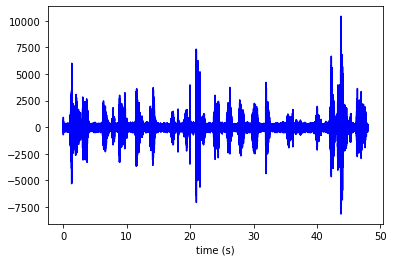

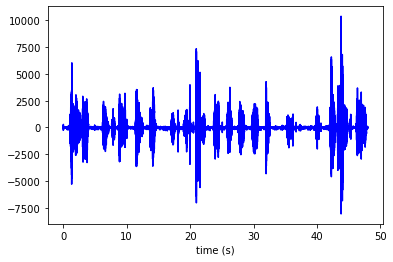

In [2]:
#wav_waveform("1.wav")
#wav_waveform("en_outfile.wav")